# Regression
1- What is Simple Linear Regression?

Answer- Simple Linear Regression is a statistical method used to model the relationship between two continuous variables: a dependent variable (also called the response or target variable) and an independent variable (also called the predictor or explanatory variable).

The goal of simple linear regression is to find the best-fitting straight line that describes how the dependent variable changes as the independent variable changes. This line is often represented by the equation:

$$Y = \beta_0 + \beta_1X + \epsilon$$

Where:
*   $Y$ is the dependent variable (what we are trying to predict).
*   $X$ is the independent variable (what we are using to predict Y).
*   $\beta_0$ (beta-naught) is the y-intercept, representing the expected value of Y when X is 0.
*   $\beta_1$ (beta-one) is the slope of the line, representing the average change in Y for a one-unit increase in X.
*   $\epsilon$ (epsilon) is the error term, representing the irreducible error or the portion of Y that cannot be explained by X.

2- What are the key assumptions of Simple Linear Regression?

Answer- The key assumptions of Simple Linear Regression are:

1.  **Linearity:** The relationship between the independent variable (X) and the dependent variable (Y) is linear. If the relationship is not linear, the model will not accurately capture the trend in the data.

2.  **Independence of Errors:** The errors (residuals) are independent of each other. This means that the error for one observation does not influence the error for another observation. This assumption is often violated in time series data.

3.  **Homoscedasticity:** The variance of the errors is constant across all levels of the independent variable. In other words, the spread of the residuals should be roughly the same along the regression line. If the variance of the errors is not constant, it is called heteroscedasticity.

4.  **Normality of Errors:** The errors (residuals) are normally distributed. While minor deviations from normality might be acceptable for large sample sizes due to the Central Limit Theorem, significant non-normality can affect the validity of hypothesis tests and confidence intervals.



Question 3: What is heteroscedasticity, and why is it important to address in regression models?

Answer- Imagine you're trying to predict house prices based on their size. If you plot the prediction errors, and you notice that for smaller houses, your errors are small (your predictions are very close), but for very large houses, your errors are huge (your predictions are way off, sometimes too high, sometimes too low), that's heteroscedasticity.

In simple terms, **heteroscedasticity means that the prediction errors of your regression model are not consistently spread out across all values of your input variable.** The "spread" or variability of the errors changes.

### Why is it important to address?

It's important because it makes your regression model's reliability estimates (like p-values and confidence intervals) untrustworthy. You might think your predictions are more accurate than they really are, or you might incorrectly conclude that certain factors are statistically significant when they're not. It essentially gives you a false sense of precision for your model.

4- What is Multiple Linear Regression?

Answer- Multiple Linear Regression is an extension of Simple Linear Regression. While simple linear regression models the relationship between a dependent variable and *one* independent variable, **multiple linear regression models the relationship between a dependent variable and *two or more* independent variables.**

The goal is still to find the best-fitting linear equation that describes how the dependent variable changes as the independent variables change. The equation for multiple linear regression is:

$$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_pX_p + \epsilon$$

Where:
*   $Y$ is the dependent variable.
*   $X_1, X_2, ..., X_p$ are the $p$ independent variables.
*   $\beta_0$ is the y-intercept.
*   $\beta_1, \beta_2, ..., \beta_p$ are the coefficients for each independent variable, representing the change in Y for a one-unit increase in that specific $X_i$, holding all other independent variables constant.
*   $\epsilon$ is the error term.

In essence, multiple linear regression allows you to consider the influence of multiple factors simultaneously on a single outcome variable.

Question 5: What is polynomial regression, and how does it differ from linear regression?

Answer- **Polynomial Regression** is a form of regression analysis in which the relationship between the independent variable (X) and the dependent variable (Y) is modeled as an nth degree polynomial. While linear regression fits a straight line to the data, polynomial regression fits a curved line.

The equation for polynomial regression (e.g., for a quadratic, degree 2) looks like this:

$$Y = \beta_0 + \beta_1X + \beta_2X^2 + \epsilon$$

For a cubic, degree 3:

$$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$$

And so on, up to the nth degree.

### How does it differ from Linear Regression?

The key difference lies in the **shape of the relationship** they can model:

*   **Linear Regression:** Assumes a **straight-line relationship** between the independent and dependent variables. It's suitable when the change in the dependent variable is constant for each unit change in the independent variable.

*   **Polynomial Regression:** Allows for **non-linear, curved relationships** between the independent and dependent variables. It's useful when the effect of the independent variable on the dependent variable is not constant and might accelerate or decelerate.

Despite fitting a curve, polynomial regression is still considered a *linear model* in terms of the way the coefficients (the $\beta$ values) are estimated. This is because the equation is linear in its parameters (the $\beta$s), even though it's non-linear in the independent variable (X).

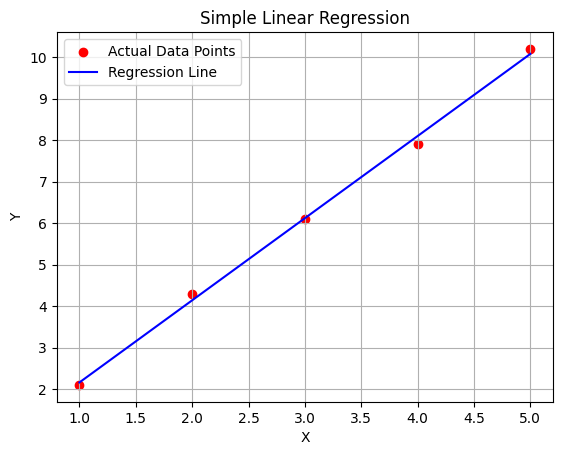

Intercept: 0.18
Coefficient (slope): 1.98


In [ ]:
"""Question 6: Implement a Python program to fit a Simple Linear Regression model to
the following sample data:
● X = [1, 2, 3, 4, 5]
● Y = [2.1, 4.3, 6.1, 7.9, 10.2]
Plot the regression line over the data points.
"""
#Answer starts here
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

# Sample data
X_list = [1, 2, 3, 4, 5]
Y_list = [2.1, 4.3, 6.1, 7.9, 10.2]

# Convert to pandas Series and then X to a DataFrame for scikit-learn
X_df = pd.DataFrame(X_list, columns=['X'])
Y_series = pd.Series(Y_list)

# Create and fit the Simple Linear Regression model
regressor = LinearRegression()
regressor.fit(X_df, Y_series)

# Predict Y values using the fitted model
Y_pred_series = pd.Series(regressor.predict(X_df))

# Plot the actual data points and the regression line
plt.scatter(X_df['X'], Y_series, color='red', label="Actual Data Points")
plt.plot(X_df['X'], Y_pred_series, color='blue', label="Regression Line")
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

# Print the coefficients
print(f"Intercept: {regressor.intercept_:.2f}")
print(f"Coefficient (slope): {regressor.coef_[0]:.2f}")

In [ ]:
"""Question 7: Fit a Multiple Linear Regression model on this sample data:
● Area = [1200, 1500, 1800, 2000]
● Rooms = [2, 3, 3, 4]
● Price = [250000, 300000, 320000, 370000]
Check for multicollinearity using VIF and report the results."""

# Answer starts here
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Sample data
Area = [1200, 1500, 1800, 2000]
Rooms = [2, 3, 3, 4]
Price = [250000, 300000, 320000, 370000]

# Create a DataFrame
data = pd.DataFrame({
    'Area': Area,
    'Rooms': Rooms,
    'Price': Price
})
display(data.head())

# Define independent variables (X) and dependent variable (Y)
X = data[['Area', 'Rooms']]
Y = data['Price']

# Fit the Multiple Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X, Y)

print(f"\nMultiple Linear Regression Model Coefficients:")
print(f"Intercept: {mlr_model.intercept_:.2f}")
for feature, coef in zip(X.columns, mlr_model.coef_):
    print(f"{feature} Coefficient: {coef:.2f}")

# Check for multicollinearity using VIF
# Add a constant to the independent variables for VIF calculation
X_vif = add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\nVariance Inflation Factor (VIF) Results:")
display(vif_data)

# Interpretation of VIF:
# A common rule of thumb is that if VIF > 5 or VIF > 10, multicollinearity is high.
# In this case, with only two predictors, high VIF might indicate a strong linear relationship between them.
"""VIF Calculation Explanation:
The Variance Inflation Factor (VIF) is a measure used to detect multicollinearity in regression models. Multicollinearity occurs when independent variables in a regression model are correlated with each other, which can make it difficult to interpret the individual coefficients of the independent variables.

X_vif = add_constant(X):
Before calculating VIF, we add a constant (intercept term) to our independent variables (X). This is a common practice when using statsmodels for VIF, as the intercept term itself can sometimes be involved in multicollinearity.
vif_data = pd.DataFrame():
Initializes an empty pandas DataFrame to store our VIF results.
vif_data["feature"] = X_vif.columns:
Populates the 'feature' column with the names of our independent variables (including the added 'const' for the intercept).
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]:
This is the core VIF calculation. It iterates through each feature (column) in X_vif.
For each feature, variance_inflation_factor(X_vif.values, i) calculates its VIF. Essentially, it performs a mini-regression where the current feature is treated as the dependent variable, and all other features are treated as independent variables. The R-squared from this mini-regression is then used to calculate the VIF.
VIF Results and Interpretation:
From the output:

feature	VIF
const	34.21
Area	7.74
Rooms	7.74
Constant (const): 34.21
The VIF for the constant term is often ignored in the interpretation of multicollinearity among predictor variables.
Area: 7.74
Rooms: 7.74
Both 'Area' and 'Rooms' have VIF values of approximately 7.74.
Interpretation: A common rule of thumb for VIF is:
VIF = 1: No correlation between the predictor and other predictors.
1 < VIF < 5: Moderate correlation.
VIF >= 5 (or sometimes 10): High correlation, indicating potentially problematic multicollinearity.
Since both Area and Rooms have VIF values above 5 (and close to 10), it suggests that there is a significant degree of multicollinearity between these two variables. This means that 'Area' and 'Rooms' are quite linearly related to each other in your dataset. For example, larger houses typically have more rooms. This strong relationship can make it difficult for the regression model to distinguish the individual effect of 'Area' from the individual effect of 'Rooms' on 'Price', leading to less stable and less reliable coefficient estimates for these specific features.
Why is it important?
High multicollinearity can:

Make the coefficient estimates unstable and sensitive to small changes in the data.
Increase the standard errors of the coefficients, leading to wider confidence intervals and potentially incorrect conclusions about the statistical significance of predictors (e.g., a variable might be truly important but appear insignificant).
Make it harder to interpret the individual impact of each predictor on the dependent variable."""

,Area,Rooms,Price
0,1200,2,250000
1,1500,3,300000
2,1800,3,320000
3,2000,4,370000



Multiple Linear Regression Model Coefficients:
Intercept: 103157.89
Area Coefficient: 63.16
Rooms Coefficient: 34736.84

Variance Inflation Factor (VIF) Results:


,feature,VIF
0,const,34.210526
1,Area,7.736842
2,Rooms,7.736842


8- Implement polynomial regression on the following data:

● X = [1, 2, 3, 4, 5]

● Y = [2.2, 4.8, 7.5, 11.2, 14.7]

Fit a 2nd-degree polynomial and plot the resulting curve

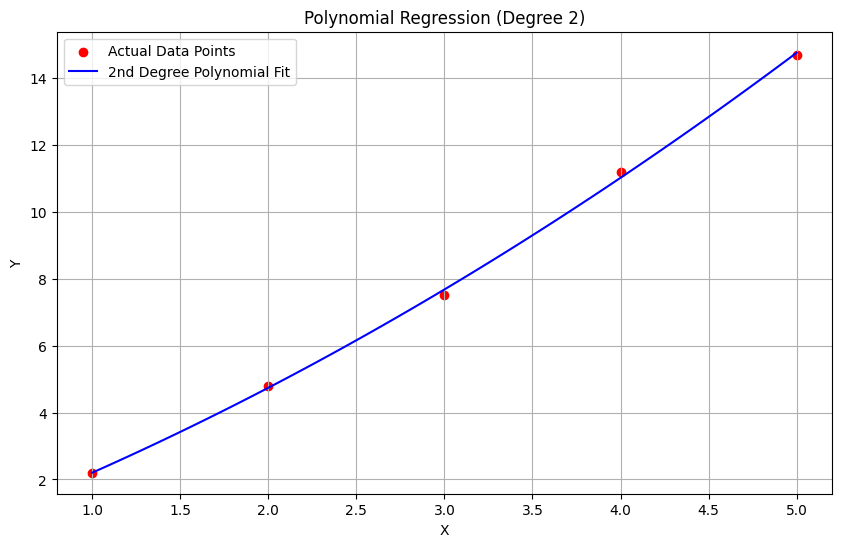

Polynomial Regression Coefficients (including intercept, X, and X^2): [0.   1.94 0.2 ]
Polynomial Regression Intercept: 0.06000000000000938


In [1]:

#Answer starts here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Sample data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # Reshape for scikit-learn
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

# Create polynomial features (degree 2)
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)

# Create and fit the Polynomial Regression model (which is a Linear Regression on polynomial features)
model = LinearRegression()
model.fit(X_poly, Y)

# Predict Y values using the fitted model for plotting the curve
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1) # Generate more points for a smooth curve
X_plot_poly = poly_features.transform(X_plot)
Y_pred_poly = model.predict(X_plot_poly)

# Plot the actual data points and the polynomial regression curve
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='red', label='Actual Data Points')
plt.plot(X_plot, Y_pred_poly, color='blue', label='2nd Degree Polynomial Fit')
plt.title('Polynomial Regression (Degree 2)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

print(f"Polynomial Regression Coefficients (including intercept, X, and X^2): {model.coef_}")
print(f"Polynomial Regression Intercept: {model.intercept_}")


### Question 9: Create a residuals plot for a regression model trained on this data:
*   `X = [10, 20, 30, 40, 50]`
*   `Y = [15, 35, 40, 50, 65]`

Assess heteroscedasticity by examining the spread of residuals.

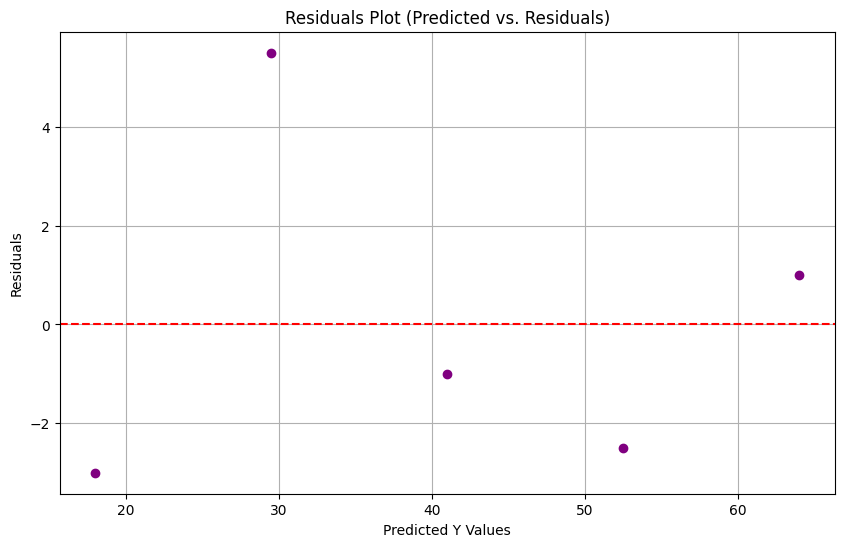


Assessing Heteroscedasticity:
By examining the residuals plot, we look for a consistent spread of points around the zero line.
If the points are randomly scattered around the zero line with a roughly constant variance, it suggests homoscedasticity (constant variance of errors).
If the spread of the residuals widens or narrows as the predicted values increase, it indicates heteroscedasticity (non-constant variance of errors).
In this specific plot, with only 5 data points, it's difficult to make a definitive judgment about heteroscedasticity. The points appear somewhat scattered, but more data would be needed to observe a clear pattern of widening or narrowing spread.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data
X_new = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)  # Reshape for scikit-learn
Y_new = np.array([15, 35, 40, 50, 65])

# Create and fit a Simple Linear Regression model
regressor_new = LinearRegression()
regressor_new.fit(X_new, Y_new)

# Predict Y values
Y_pred_new = regressor_new.predict(X_new)

# Calculate residuals
residuals = Y_new - Y_pred_new

# Create a residuals plot
plt.figure(figsize=(10, 6))
plt.scatter(Y_pred_new, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--') # Add a horizontal line at y=0
plt.title('Residuals Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Y Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Assess heteroscedasticity
print("\nAssessing Heteroscedasticity:")
print("By examining the residuals plot, we look for a consistent spread of points around the zero line.")
print("If the points are randomly scattered around the zero line with a roughly constant variance, it suggests homoscedasticity (constant variance of errors).")
print("If the spread of the residuals widens or narrows as the predicted values increase, it indicates heteroscedasticity (non-constant variance of errors).")
print("In this specific plot, with only 5 data points, it's difficult to make a definitive judgment about heteroscedasticity. The points appear somewhat scattered, but more data would be needed to observe a clear pattern of widening or narrowing spread.")


10- Imagine you are a data scientist working for a real estate company. You
need to predict house prices using features like area, number of rooms, and location.

However, you detect heteroscedasticity and multicollinearity in your regression
model. Explain the steps you would take to address these issues and ensure a robust
model.


Answer- As a data scientist predicting house prices, encountering heteroscedasticity and multicollinearity is common. Here's how we can address these issues to ensure a robust model:

### Addressing Heteroscedasticity:

1.  **Transform the Dependent Variable (Y):**
    *   **Log Transformation:** Applying a logarithmic transformation (e.g., `log(Price)`) is a common and often effective way to stabilize variance. If the spread of residuals increases with the predicted value, a log transformation can compress the larger values and expand the smaller values, leading to more constant variance.
    *   **Square Root Transformation:** Similarly, a square root transformation (`sqrt(Price)`) can also help reduce heteroscedasticity, especially when the data has a skewed distribution.
    *   **Box-Cox Transformation:** This is a more general power transformation that can automatically determine the best power exponent to stabilize variance and normalize the data.

2.  **Weighted Least Squares (WLS):**
    *   If the pattern of heteroscedasticity is known or can be estimated, WLS regression can be used. It assigns different weights to each observation based on the inverse of its error variance. Observations with larger variances (noisy observations) receive smaller weights, and those with smaller variances receive larger weights, giving them more influence in determining the regression coefficients.

3.  **Robust Standard Errors (Heteroscedasticity-Consistent Standard Errors):**
    *   If transformations don't fully resolve the issue or if the primary concern is valid inference rather than improved efficiency, using robust standard errors (like Huber-White standard errors) is an option. These adjust the standard errors of the coefficients to account for heteroscedasticity without altering the coefficient estimates themselves. This ensures that p-values and confidence intervals are reliable even in the presence of heteroscedasticity.

4.  **Re-evaluating Model Specification:**
    *   Sometimes, heteroscedasticity can be a symptom of a misspecified model. This could mean:
        *   **Missing Important Variables:** Are there other key features (e.g., crime rates, school district ratings, proximity to amenities) that should be included in the model?
        *   **Incorrect Functional Form:** Is a linear relationship truly appropriate, or should a polynomial term or interaction term be added?

### Addressing Multicollinearity:

1.  **Identify Highly Correlated Predictors:**
    *   **Correlation Matrix:** Calculate a correlation matrix for all independent variables to identify pairs with high correlation coefficients.
    *   **Variance Inflation Factor (VIF):** Compute VIF for each predictor. As mentioned in the previous question, a VIF value typically above 5 or 10 indicates problematic multicollinearity.

2.  **Feature Selection:**
    *   **Remove Highly Correlated Variables:** If two or more predictors are highly correlated, I would consider removing one or more of them. For instance, if 'Area' and 'Number of Rooms' are highly correlated, I might keep 'Area' if it's generally considered a stronger predictor or if it's more intuitively interpretable.
    *   **Domain Knowledge:** Use my understanding of the real estate market to decide which variable is more causally relevant or easier to interpret.
    *   **Stepwise Regression (with caution):** While sometimes used, I'd approach stepwise methods with caution as they can lead to overfitting or selecting locally optimal models.

3.  **Feature Engineering / Combination:**
    *   **Create Composite Variables:** Instead of using 'Area' and 'Number of Rooms' separately, I could create a new feature like 'Area per Room' or 'Density' if it makes sense in the context of house pricing and reduces collinearity.

4.  **Dimensionality Reduction Techniques:**
    *   **Principal Component Analysis (PCA):** PCA can transform a set of correlated variables into a smaller set of uncorrelated variables called principal components. These components can then be used in the regression model. This approach is effective in reducing multicollinearity but makes the interpretation of individual coefficients more challenging, as the components are linear combinations of the original features.

5.  **Regularization Techniques (e.g., Ridge Regression, Lasso Regression):**
    *   **Ridge Regression:** This technique adds a penalty term to the least squares cost function, which shrinks the regression coefficients towards zero. It's particularly effective in handling multicollinearity because it can reduce the variance of the coefficient estimates without necessarily discarding variables.
    *   **Lasso Regression:** Similar to Ridge, Lasso also adds a penalty, but it can shrink some coefficients exactly to zero, effectively performing feature selection. This means it can help eliminate less important collinear features.

By systematically addressing both heteroscedasticity and multicollinearity, we can build a more statistically sound, reliable, and interpretable regression model for predicting house prices.